<a href="https://colab.research.google.com/github/Yoloez/AI_Kelompok_8/blob/main/AI_KEL_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd


In [ ]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:

path = kagglehub.dataset_download("itanium/livin-by-mandiri-app-reviews")

print("Path to dataset files:", path)

100%|██████████| 4.02M/4.02M [00:00<00:00, 190MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/itanium/livin-by-mandiri-app-reviews/versions/2


In [ ]:
files = os.listdir(path)
print("File yang tersedia:", files)

csv_file_path = os.path.join(path, files[0])
df = pd.read_csv(csv_file_path)
df.head()

File yang tersedia: ['reviews.csv']


,date,review,rating,thumbs_up,version
0,2021-09-30 06:12:53,"Udah di coba, keren dan responsive, dengan tam...",5,36,1.0.0
1,2021-09-30 06:33:15,Excellent,5,0,1.0.0
2,2021-09-30 06:48:30,Keren. Cakep benar semakin canggih. Terdepan t...,5,22,1.0.0
3,2021-09-30 06:56:05,mantap,5,0,NaN
4,2021-09-30 07:02:21,Mantap,5,0,1.0.0


In [ ]:
print("\n--- 5 Data Teratas ---")
print(df.head())


--- 5 Data Teratas ---
                  date                                             review  \
0  2021-09-30 06:12:53  Udah di coba, keren dan responsive, dengan tam...   
1  2021-09-30 06:33:15                                          Excellent   
2  2021-09-30 06:48:30  Keren. Cakep benar semakin canggih. Terdepan t...   
3  2021-09-30 06:56:05                                             mantap   
4  2021-09-30 07:02:21                                             Mantap   

   rating  thumbs_up version  
0       5         36   1.0.0  
1       5          0   1.0.0  
2       5         22   1.0.0  
3       5          0     NaN  
4       5          0   1.0.0  


In [ ]:
print(f"Total baris data: {df.shape[0]} baris")

Total baris data: 155192 baris


In [ ]:
# Menghitung rata-rata rating dan jumlah ulasan per versi aplikasi
version_stats = df.groupby('version')['rating'].agg(['mean', 'count']).reset_index()
version_stats.rename(columns={'mean': 'average_rating', 'count': 'number_of_reviews'}, inplace=True)

# Menampilkan hasilnya
print("\nRata-rata Rating dan Jumlah Ulasan per Versi Aplikasi:")
display(version_stats.sort_values(by='average_rating', ascending=False))


Rata-rata Rating dan Jumlah Ulasan per Versi Aplikasi:


,version,average_rating,number_of_reviews
0,0.2.5,5.000000,1
4,1.0.3,5.000000,4
5,1.1.0,4.115253,24789
1,1.0.0,3.991193,10900
6,1.1.1,3.876841,18675
7,1.1.2,3.584916,5317
8,1.1.3,3.393477,7083
2,1.0.1,3.211043,6719
3,1.0.2,3.166986,43902
9,1.2.0,3.033233,1324


/tmp/ipykernel_516/652879785.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='version', y='average_rating', data=version_stats.sort_values(by='average_rating', ascending=False), palette='viridis')


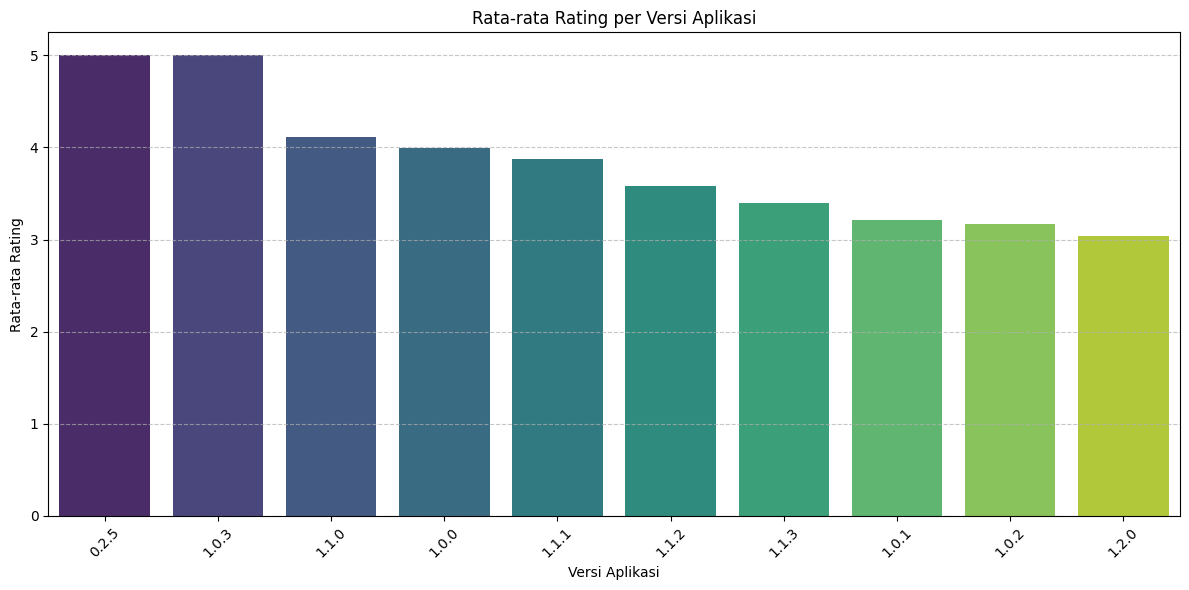

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='version', y='average_rating', data=version_stats.sort_values(by='average_rating', ascending=False), palette='viridis')
plt.title('Rata-rata Rating per Versi Aplikasi')
plt.xlabel('Versi Aplikasi')
plt.ylabel('Rata-rata Rating')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Data Preprocessing

In [ ]:
# Memeriksa missing values
print("Jumlah missing values per kolom:")
display(df.isnull().sum())

Jumlah missing values per kolom:


,0
date,0
review,0
rating,0
thumbs_up,0
version,36478


In [ ]:
# Mengisi missing values di kolom 'version' dengan 'Unknown'
df['version'].fillna('Unknown', inplace=True)

# Memeriksa kembali missing values setelah imputasi
print("Jumlah missing values per kolom setelah imputasi:")
display(df.isnull().sum())

Jumlah missing values per kolom setelah imputasi:


/tmp/ipykernel_516/4109714488.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['version'].fillna('Unknown', inplace=True)


,0
date,0
review,0
rating,0
thumbs_up,0
version,0


In [ ]:
import re

def clean_text(text):
    # 1. Mengubah ke lowercase
    text = str(text).lower()
    # 2. Menghapus emoji dan karakter non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # 3. Menghapus karakter khusus/tanda baca dan angka
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# PERBAIKAN: Terapkan pembersihan pada 'df' (data mentah awal)
print("Sedang membersihkan data...")
df['review_cleaned'] = df['review'].apply(clean_text)

# Menampilkan perbandingan sebelum dan sesudah
display(df[['review', 'review_cleaned']].head())
print("\nPembersihan selesai!")

Sedang membersihkan data...


,review,review_cleaned
0,"Udah di coba, keren dan responsive, dengan tam...",udah di coba keren dan responsive dengan tampi...
1,Excellent,excellent
2,Keren. Cakep benar semakin canggih. Terdepan t...,keren cakep benar semakin canggih terdepan ter...
3,mantap,mantap
4,Mantap,mantap



Pembersihan selesai!


### Perbandingan Statistik dan Visualisasi Sebelum vs Sesudah Balancing


Tabel Jumlah Review per Rating:


,Jumlah Review,count
0,1,39183
1,2,9379
2,3,9464
3,4,10951
4,5,86215


/tmp/ipykernel_516/2725074780.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


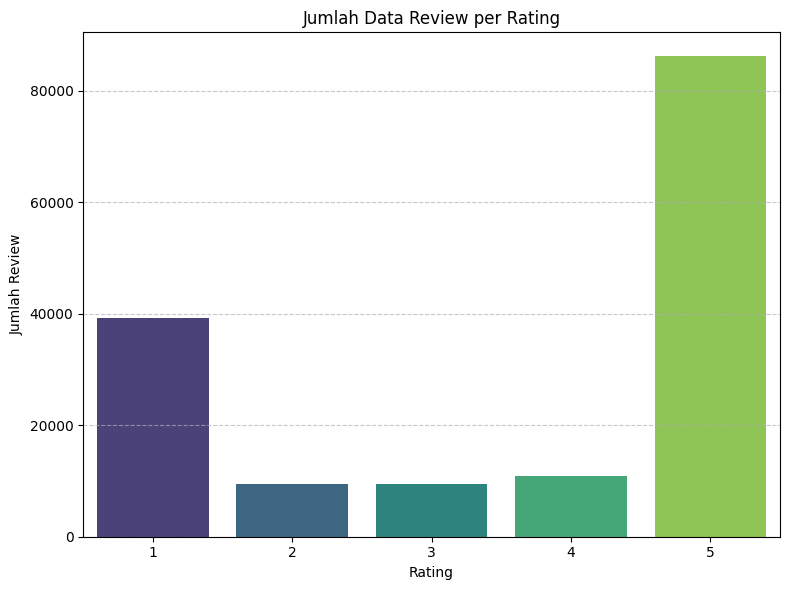

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah review untuk setiap rating
rating_counts = df['rating'].value_counts().sort_index()

print("\nTabel Jumlah Review per Rating:")
display(rating_counts.reset_index().rename(columns={'index': 'Rating', 'rating': 'Jumlah Review'}))

# Membuat visualisasi
plt.figure(figsize=(8, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Jumlah Data Review per Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)

Index(['date', 'review', 'rating', 'thumbs_up', 'version', 'review_cleaned'], dtype='object')


In [ ]:
import pandas as pd
from sklearn.utils import resample

df_proses = df.copy()


# 2. BUAT LABEL SENTIMEN
def create_label(rating):
    if rating >= 4:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Negatif'

df_proses['sentiment_label'] = df_proses['rating'].apply(create_label)


# 3. CEK DISTRIBUSI AWAL
print("Distribusi sebelum balancing:")
print(df_proses['sentiment_label'].value_counts())


# 4. PISAHKAN TIAP KELAS
df_pos = df_proses[df_proses['sentiment_label'] == 'Positif']
df_neg = df_proses[df_proses['sentiment_label'] == 'Negatif']
df_net = df_proses[df_proses['sentiment_label'] == 'Netral']


# 5. TENTUKAN JUMLAH MINIMUM
min_count = min(len(df_pos), len(df_neg), len(df_net))

print("\nJumlah minimum:", min_count)


# 6. RANDOM UNDERSAMPLING
df_pos_under = resample(
    df_pos,
    replace=False,
    n_samples=min_count,
    random_state=42
)

df_neg_under = resample(
    df_neg,
    replace=False,
    n_samples=min_count,
    random_state=42
)

df_net_under = resample(
    df_net,
    replace=False,
    n_samples=min_count,
    random_state=42
)


# 7. GABUNGKAN KEMBALI
df_balanced = pd.concat([
    df_pos_under,
    df_neg_under,
    df_net_under
])

# acak ulang
df_balanced = df_balanced.sample(frac=1, random_state=42)

# 8. CEK HASIL
print("\nDistribusi setelah undersampling:")
print(df_balanced['sentiment_label'].value_counts())

Distribusi sebelum balancing:
sentiment_label
Positif    97166
Negatif    48562
Netral      9464
Name: count, dtype: int64

Jumlah minimum: 9464

Distribusi setelah undersampling:
sentiment_label
Netral     9464
Negatif    9464
Positif    9464
Name: count, dtype: int64



[INFO] Setiap label akan dipotong rata menjadi: 9464 baris

--- KONDISI SESUDAH UNDERSAMPLING ---
sentiment_label
Positif    9464
Negatif    9464
Netral     9464
Name: count, dtype: int64


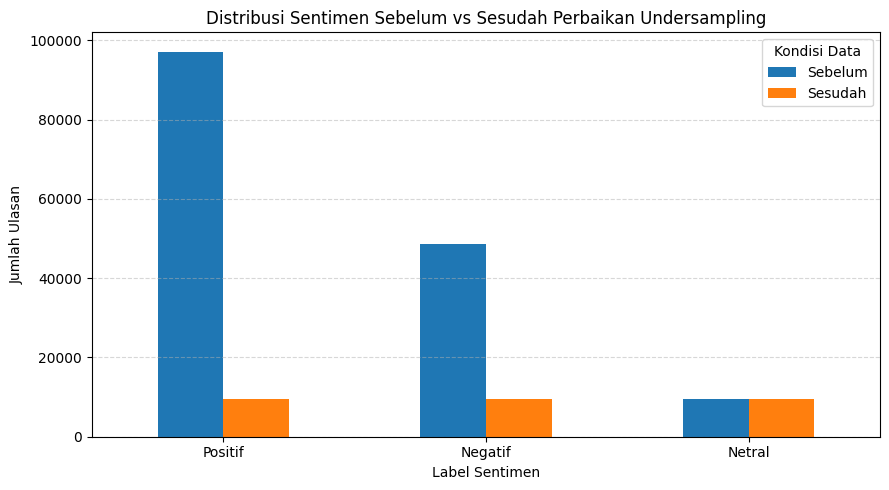

In [ ]:
from sklearn.utils import resample
import matplotlib.pyplot as plt

before_counts = df_proses['sentiment_label'].value_counts()
min_label_count = before_counts.min()
print(f"\n[INFO] Setiap label akan dipotong rata menjadi: {min_label_count} baris")

df_list = []
for label_val in before_counts.index:
    df_sentiment = df_proses[df_proses.sentiment_label == label_val]

    if len(df_sentiment) > min_label_count:
        df_sampled = resample(df_sentiment,
                              replace=False,
                              n_samples=min_label_count,
                              random_state=42)
        df_list.append(df_sampled)
    else:
        df_list.append(df_sentiment)

# Gabungkan menjadi DataFrame final yang BENAR-BENAR SEIMBANG
df_final_balanced = pd.concat(df_list)


# 3. VERIFIKASI HASIL AKHIR
after_counts = df_final_balanced['sentiment_label'].value_counts()
print("\n--- KONDISI SESUDAH UNDERSAMPLING ---")
print(after_counts)

# Visualisasi grafik batang untuk laporan kelompok
comparison_df = pd.DataFrame({
    'Sebelum': before_counts,
    'Sesudah': after_counts
})

comparison_df.plot(kind='bar', figsize=(9, 5))
plt.title('Distribusi Sentimen Sebelum vs Sesudah Perbaikan Undersampling')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Kondisi Data')
plt.tight_layout()
plt.show()

### SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

# Define the features (X) and target (y) from the balanced dataframe
X_text = df_final_balanced['review']
y = df_final_balanced['sentiment_label']

# Split the data into training and testing sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah Training:", len(X_train_text))
print("Jumlah Testing :", len(X_test_text))

Jumlah Training: 22713
Jumlah Testing : 5679


### TF IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat TF-IDF dengan data yang sudah bersih
tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1, 2))

# Fit dan transform menggunakan X_train_text yang sudah bersih
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF berhasil dibuat dengan data bersih.")
print("Shape X_train:", X_train.shape)

TF-IDF berhasil dibuat dengan data bersih.
Shape X_train: (22713, 6000)


## LOGISTIC REGRESSION

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[INFO] Model Logistic Regression berhasil dilatih menggunakan fitur TF-IDF!

--- LAPORAN EVALUASI MODEL BARU ---
              precision    recall  f1-score   support

     Negatif       0.65      0.65      0.65      1893
      Netral       0.56      0.52      0.54      1893
     Positif       0.80      0.85      0.83      1893

    accuracy                           0.68      5679
   macro avg       0.67      0.68      0.67      5679
weighted avg       0.67      0.68      0.67      5679



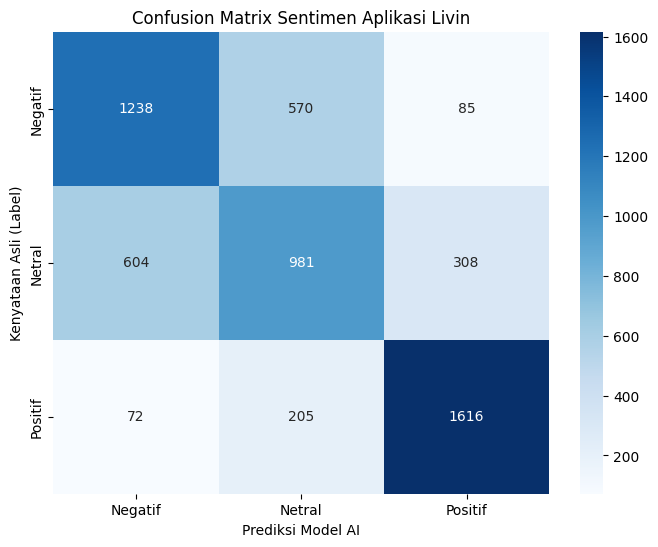

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# 1. MEMANGGIL OTAK AI (LOGISTIC REGRESSION MULTINOMIAL)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)


# 2. PROSES SUPERVISED LEARNING (PROSES BELAJAR / TRAINING)
model.fit(X_train, y_train)

print("[INFO] Model Logistic Regression berhasil dilatih menggunakan fitur TF-IDF!\n")



# 3. PROSES UJIAN (PREDIKSI DATA TESTING)
y_pred = model.predict(X_test)



# 4. MENAMPILKAN HASIL EVALUASI (RAPOT NILAI AI)
print("--- LAPORAN EVALUASI MODEL BARU ---")
print(classification_report(y_test, y_pred))


# 5. VISUALISASI CONFUSION MATRIX (GRAFIK SALAH TEBAK)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Prediksi Model AI')
plt.ylabel('Kenyataan Asli (Label)')
plt.title('Confusion Matrix Sentimen Aplikasi Livin')
plt.show()

## UJI COBA

In [ ]:
def prediksi_sentimen_aplikasi(kalimat_baru):
    # 1. Bersihkan kalimat menggunakan fungsi preprocessing yang sudah kita buat
    kalimat_bersih = clean_text(kalimat_baru)

    # 2. Ubah kalimat menjadi angka menggunakan mesin TF-IDF yang sudah dilatih
    kalimat_vektor = tfidf.transform([kalimat_bersih])

    # 3. Minta Logistic Regression menebak labelnya
    tebak_label = model.predict(kalimat_vektor)

    # 4. Minta model mengeluarkan persentase keyakinannya (Probabilitas Softmax)
    probabilitas = model.predict_proba(kalimat_vektor)[0]
    maks_prob = max(probabilitas) * 100

    print(f"Ulasan Nasabah : '{kalimat_baru}'")
    print(f"Hasil Prediksi : {tebak_label[0]} ({maks_prob:.2f}% yakin)")
    print("-" * 50)

# --- SILAKAN EDIT ATAU TAMBAH KALIMAT DI BAWAH INI UNTUK MENCOBA ---
prediksi_sentimen_aplikasi("Fitur transfer terbarunya lancar jaya, ga pake loading lama!")
prediksi_sentimen_aplikasi("Biasa aja sih, tidak ada yang istimewa dibanding m-banking lain.")
prediksi_sentimen_aplikasi("Aplikasi error terus setelah diupdate, kecewa banget saldo ga muncul!!")
prediksi_sentimen_aplikasi("Gimana sih ini aplikasinya kok jelek banget")
prediksi_sentimen_aplikasi("kamu ganteng banget, ")
prediksi_sentimen_aplikasi("PT Vilabs is pretty cool for virtual labs and their customer support is quick to respond. Plus, their features are quite")

Ulasan Nasabah : 'Fitur transfer terbarunya lancar jaya, ga pake loading lama!'
Hasil Prediksi : Positif (47.76% yakin)
--------------------------------------------------
Ulasan Nasabah : 'Biasa aja sih, tidak ada yang istimewa dibanding m-banking lain.'
Hasil Prediksi : Netral (53.16% yakin)
--------------------------------------------------
Ulasan Nasabah : 'Aplikasi error terus setelah diupdate, kecewa banget saldo ga muncul!!'
Hasil Prediksi : Negatif (92.67% yakin)
--------------------------------------------------
Ulasan Nasabah : 'Gimana sih ini aplikasinya kok jelek banget'
Hasil Prediksi : Negatif (83.97% yakin)
--------------------------------------------------
Ulasan Nasabah : 'kamu ganteng banget, '
Hasil Prediksi : Positif (44.55% yakin)
--------------------------------------------------
Ulasan Nasabah : 'PT Vilabs is pretty cool for virtual labs and their customer support is quick to respond. Plus, their features are quite'
Hasil Prediksi : Positif (46.34% yakin)
--------

In [ ]:
# ========================================================
# 1. INSTALL LIBRARY YANG DIBUTUHKAN
# ========================================================
!pip install -q transformers datasets accelerate evaluate

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import evaluate

# Pastikan GPU terdeteksi
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Menggunakan perangkat: {device.upper()}")


# ========================================================
# 2. KONVERSI LABEL STR (POSITIF/NETRAL/NEGATIF) KE ANGKA
# ========================================================
# BERT membutuhkan label dalam bentuk indeks angka (0, 1, 2)
label_mapping = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
inverse_label_mapping = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

y_train_numeric = y_train.map(label_mapping).tolist()
y_test_numeric = y_test.map(label_mapping).tolist()


# ========================================================
# 3. SIAPKAN DATASET FORMAT HUGGING FACE
# ========================================================
# Kita gabungkan teks mentah hasil split dengan label angka baru
train_df = pd.DataFrame({'text': X_train_text.tolist(), 'label': y_train_numeric})
test_df = pd.DataFrame({'text': X_test_text.tolist(), 'label': y_test_numeric})

# Ubah pandas DataFrame menjadi Hugging Face Dataset object
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


# ========================================================
# 4. LOAD TOKENIZER INDOBERT
# ========================================================
# Tokenizer berfungsi memotong kalimat menjadi sub-kata yang dipahami IndoBERT
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("[INFO] Sedang melakukan tokenisasi data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)


# ========================================================
# 5. LOAD MODEL INDOBERT (UNTUK 3 KELAS)
# ========================================================
# num_labels=3 karena kita punya kelas Positif, Netral, dan Negatif
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
model.to(device)


# ========================================================
# 6. ATUR METRIK EVALUASI (ACCURACY & F1-SCORE)
# ========================================================
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    # Gunakan average='macro' karena kita mengevaluasi multiclass yang sudah seimbang
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]

    return {"accuracy": acc, "f1_macro": f1_macro}


# ========================================================
# 7. SETTING PARAMETER TRAINING (TRAINING ARGUMENTS)
# ========================================================
training_args = TrainingArguments(
    output_dir="./results_indobert",      # Folder penyimpan model
    eval_strategy="epoch",                # Evaluasi performa setiap selesai 1 epoch
    save_strategy="epoch",                # Simpan checkpoint setiap epoch
    learning_rate=2e-5,                   # Nilai lr standar untuk fine-tuning BERT
    per_device_train_batch_size=16,       # Jumlah data per batch latihan
    per_device_eval_batch_size=16,        # Jumlah data per batch uji
    num_train_epochs=3,                   # Model belajar mengitari seluruh dataset sebanyak 3 kali
    weight_decay=0.01,                    # Regularisasi agar tidak overfitting
    load_best_model_at_end=True,          # Di akhir, ambil model dengan performa terbaik
    metric_for_best_model="f1_macro",     # Acuan penentu model terbaik berdasarkan F1-Macro
    logging_dir="./logs",                 # Folder log training
    logging_steps=50,                     # Munculkan log setiap 50 langkah
    report_to="none"                      # Matikan sinkronisasi ke cloud luar
)


# ========================================================
# 8. JALANKAN PROSES FINE-TUNING (TRAINER)
# ========================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("\n🚀 MEMULAI PROSES TRAINING INDOBERT... SILAKAN TUNGGU 🚀")
trainer.train()
print("\n[INFO] Training Selesai Sempurna!")

[INFO] Menggunakan perangkat: CUDA


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


[INFO] Training Selesai Sempurna!


[INFO] Sedang mengambil prediksi dari data testing menggunakan IndoBERT...



--- LAPORAN EVALUASI MODEL INDOBERT ---
              precision    recall  f1-score   support

     Negatif       0.66      0.60      0.63      1893
      Netral       0.55      0.53      0.54      1893
     Positif       0.76      0.86      0.81      1893

    accuracy                           0.66      5679
   macro avg       0.66      0.66      0.66      5679
weighted avg       0.66      0.66      0.66      5679



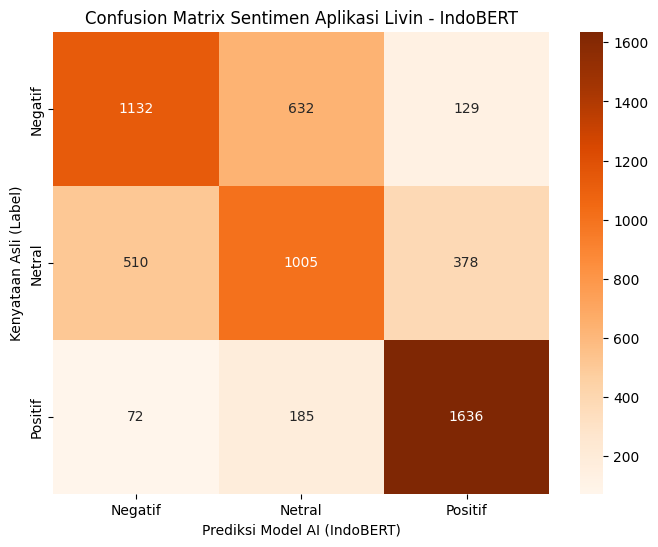

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("[INFO] Sedang mengambil prediksi dari data testing menggunakan IndoBERT...")

# 1. Ambil prediksi mentah (logits) dari model IndoBERT menggunakan objek trainer
raw_predictions = trainer.predict(tokenized_test)

# 2. Ambil nilai logits dan ubah menjadi indeks angka (0, 1, atau 2) menggunakan argmax
y_pred_indobert_numeric = np.argmax(raw_predictions.predictions, axis=-1)

# 3. Ambil kunci jawaban asli (y_test_numeric sudah didefinisikan di cell sebelumnya)
y_true_numeric = y_test_numeric

# 4. Petakan kembali angka (0, 1, 2) ke teks asli agar grafiknya mudah dibaca dosen
target_names = ['Negatif', 'Netral', 'Positif']


# ========================================================
# 5. TAMPILKAN RAPOT KLASIFIKASI INDOBERT
# ========================================================
print("\n--- LAPORAN EVALUASI MODEL INDOBERT ---")
print(classification_report(y_true_numeric, y_pred_indobert_numeric, target_names=target_names))


# ========================================================
# 6. VISUALISASI CONFUSION MATRIX INDOBERT
# ========================================================
cm_indobert = confusion_matrix(y_true_numeric, y_pred_indobert_numeric)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_indobert, annot=True, fmt='d', cmap='Oranges', # Kita pakai warna Oranye biar beda dengan Logistic Regression
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Prediksi Model AI (IndoBERT)')
plt.ylabel('Kenyataan Asli (Label)')
plt.title('Confusion Matrix Sentimen Aplikasi Livin - IndoBERT')
plt.show()

[INFO] Sedang mengumpulkan data prediksi dari IndoBERT...


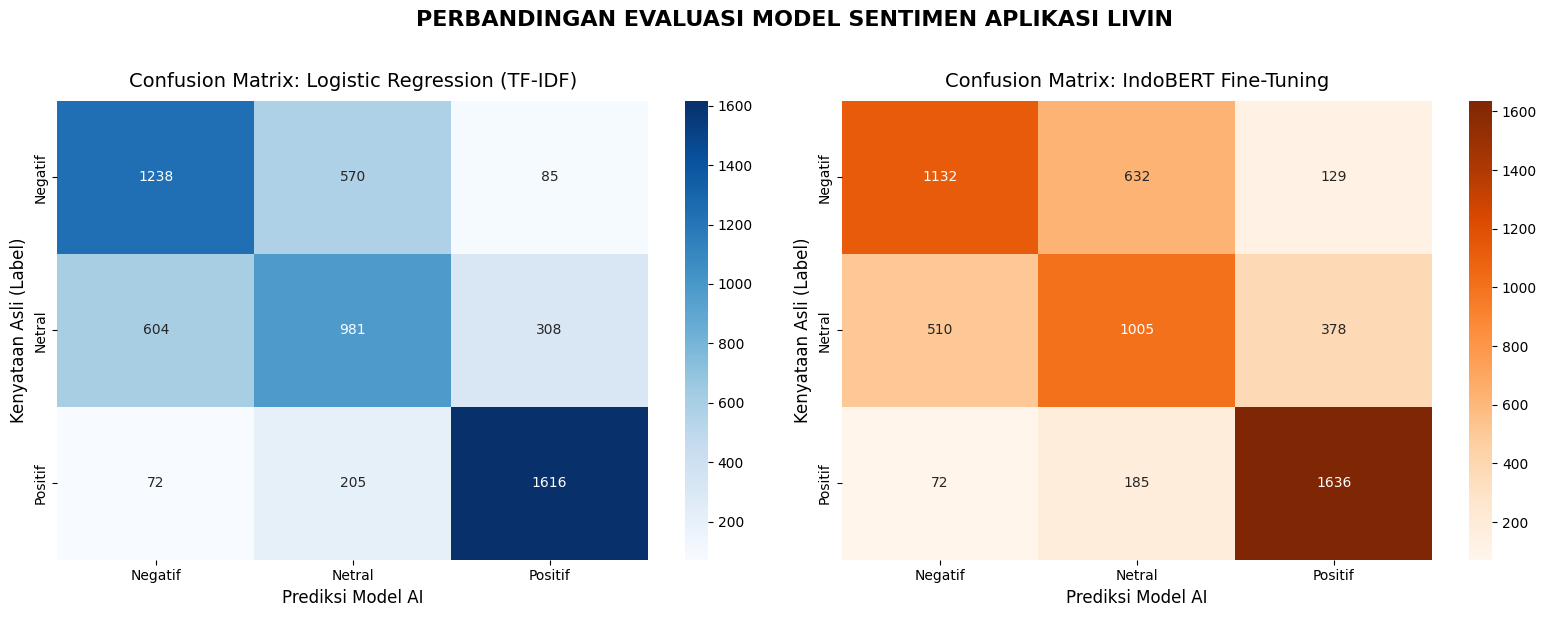


     PERBANDINGAN LAPORAN EVALUASI (TEXTUAL REPORT)

[1] METRIK LOGISTIC REGRESSION:
              precision    recall  f1-score   support

     Negatif       0.65      0.65      0.65      1893
      Netral       0.56      0.52      0.54      1893
     Positif       0.80      0.85      0.83      1893

    accuracy                           0.68      5679
   macro avg       0.67      0.68      0.67      5679
weighted avg       0.67      0.68      0.67      5679


[2] METRIK INDOBERT FINE-TUNING:
              precision    recall  f1-score   support

     Negatif       0.66      0.60      0.63      1893
      Netral       0.55      0.53      0.54      1893
     Positif       0.76      0.86      0.81      1893

    accuracy                           0.66      5679
   macro avg       0.66      0.66      0.66      5679
weighted avg       0.66      0.66      0.66      5679



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ========================================================
# 1. AMBIL PREDIKSI DARI KEDUA MODEL
# ========================================================
# A. Prediksi dari Logistic Regression (Sudah kita lakukan di cell atas)
# Variabel y_pred (milik Logistic Regression) dan y_test (label asli berbentuk teks)

# B. Ambil Prediksi dari IndoBERT (Menggunakan objek trainer)
print("[INFO] Sedang mengumpulkan data prediksi dari IndoBERT...")
raw_predictions = trainer.predict(tokenized_test)
y_pred_indobert_numeric = np.argmax(raw_predictions.predictions, axis=-1)

# Petakan kunci jawaban asli ke dalam bentuk teks agar seragam
target_names = ['Negatif', 'Netral', 'Positif']
y_test_text = y_test.tolist() # Memastikan bentuknya list teks: ['Positif', 'Netral', ...]

# Petakan hasil prediksi angka IndoBERT (0,1,2) ke teks kembali
inverse_label_mapping = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
y_pred_indobert_text = [inverse_label_mapping[idx] for idx in y_pred_indobert_numeric]


# ========================================================
# 2. HITUNG CONFUSION MATRIX MASING-MASING MODEL
# ========================================================
cm_logistic = confusion_matrix(y_test_text, y_pred, labels=target_names)
cm_indobert = confusion_matrix(y_test_text, y_pred_indobert_text, labels=target_names)


# ========================================================
# 3. PROSES PLOTTING BERDAMPINGAN (SIDE-BY-SIDE)
# ========================================================
# Kita buat canvas dengan 1 baris dan 2 kolom (figsize lebar agar muat berdua)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFIK KIRI: LOGISTIC REGRESSION ---
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names, cbar=True)
axes[0].set_title('Confusion Matrix: Logistic Regression (TF-IDF)', fontsize=14, pad=10)
axes[0].set_xlabel('Prediksi Model AI', fontsize=12)
axes[0].set_ylabel('Kenyataan Asli (Label)', fontsize=12)

# --- GRAFIK KANAN: INDOBERT ---
sns.heatmap(cm_indobert, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names, cbar=True)
axes[1].set_title('Confusion Matrix: IndoBERT Fine-Tuning', fontsize=14, pad=10)
axes[1].set_xlabel('Prediksi Model AI', fontsize=12)
axes[1].set_ylabel('Kenyataan Asli (Label)', fontsize=12)

# Rapikan tata letak agar tidak saling bertabrakan
plt.suptitle('PERBANDINGAN EVALUASI MODEL SENTIMEN APLIKASI LIVIN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan gambar secara otomatis ke dalam folder Colab agar siap di-download untuk PPT
plt.savefig('perbandingan_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()


# ========================================================
# 4. CETAK PERBANDINGAN RAPOT TEKS DI TERMINAL
# ========================================================
print("\n" + "="*60)
print("     PERBANDINGAN LAPORAN EVALUASI (TEXTUAL REPORT)")
print("="*60)
print("\n[1] METRIK LOGISTIC REGRESSION:")
print(classification_report(y_test_text, y_pred, target_names=target_names))

print("\n[2] METRIK INDOBERT FINE-TUNING:")
print(classification_report(y_test_text, y_pred_indobert_text, target_names=target_names))